# Group Project DA 
Ethan CT - 2802394834
Brandon MA - 2802418512
Marvelle KL - 2802424433

In [1]:
#Dataset yang digunakan saat ini terlalu besar (1 million rows) sehingga saya hanya akan mengambil sample 
# sebanyak 50k rows untuk analisis.
import pandas as pd

CSV_PATH = "instagram_usage_lifestyle.csv"  

df_full = pd.read_csv(CSV_PATH, nrows=500_000)
df_sample = df_full.sample(n=50_000, random_state=42).reset_index(drop=True)
df_sample.to_csv("instagram_50k.csv", index=False)

print(f"Saved 50k sample, shape: {df_sample.shape}")

Saved 50k sample, shape: (50000, 58)


Imports & load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("instagram_50k.csv")

print(f"Shape: {df.shape}")
df.head(5)

Shape: (50000, 58)


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,104242,Instagram,35,Female,India,Urban,Middle,Freelancer,Bachelor’s,Married,...,2025-07-22,14.8,Stories,Food,Public,Yes,No,2,Free,1.00
1,199677,Instagram,34,Male,India,Suburban,Middle,Freelancer,PhD,Divorced,...,2025-08-11,13.0,Live,Art,Friends only,No,No,2,Free,4.71
2,140200,Instagram,38,Prefer not to say,South Korea,Suburban,High,Part-time,Some college,Single,...,2025-09-15,23.2,Reels,Food,Public,No,No,1,Free,1.03
3,132815,Instagram,47,Male,Canada,Urban,Middle,Full-time employed,Bachelor’s,Divorced,...,2026-01-02,29.0,Videos,Fitness,Friends only,Yes,No,3,Free,2.07
4,408698,Instagram,34,Female,United States,Urban,Lower-middle,Part-time,Bachelor’s,Married,...,2025-11-19,13.0,Photos,Music,Private,Yes,No,0,Free,1.43


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   app_name                        50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   gender                          50000 non-null  object 
 4   country                         50000 non-null  object 
 5   urban_rural                     50000 non-null  object 
 6   income_level                    50000 non-null  object 
 7   employment_status               50000 non-null  object 
 8   education_level                 50000 non-null  object 
 9   relationship_status             50000 non-null  object 
 10  has_children                    50000 non-null  object 
 11  exercise_hours_per_week         50000 non-null  float64
 12  sleep_hours_per_night           

Checking dataset description

In [4]:
df.describe()

,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,249883.704280,38.989800,7.184180,7.000860,19.995760,5.491100,24.987316,124.724920,79.538300,7999.700660,...,37.635560,32.975880,56.532480,2140.22568,2582.514720,0.498868,2017.498860,20.525210,1.977620,1.636521
std,144426.397767,15.321535,3.994442,1.097441,11.835843,2.875817,3.980420,20.212524,11.561085,89.160983,...,25.455981,21.521862,35.459779,3364.51772,2725.774763,0.289575,4.611874,8.685764,1.348939,1.792311
min,7.000000,13.000000,0.000000,3.000000,0.000000,1.000000,15.000000,90.000000,60.000000,7611.000000,...,1.000000,1.000000,1.000000,10.00000,20.000000,0.000000,2010.000000,5.000000,0.000000,0.680000
25%,124833.250000,26.000000,4.100000,6.300000,10.000000,3.000000,22.300000,107.000000,70.000000,7940.000000,...,18.000000,16.000000,29.000000,544.00000,666.000000,0.250000,2013.000000,13.300000,1.000000,1.000000
50%,249660.500000,39.000000,6.700000,7.000000,20.000000,5.000000,25.000000,125.000000,80.000000,7999.000000,...,34.000000,30.000000,54.000000,1148.50000,1508.000000,0.500000,2018.000000,20.400000,2.000000,1.100000
75%,375707.000000,52.000000,9.800000,7.700000,30.000000,8.000000,27.700000,142.000000,90.000000,8060.000000,...,53.000000,47.000000,80.000000,2424.00000,3410.000000,0.750000,2022.000000,27.700000,3.000000,1.290000
max,500000.000000,65.000000,24.000000,10.000000,40.000000,10.000000,42.500000,159.000000,99.000000,8374.000000,...,147.000000,124.000000,196.000000,155286.00000,10000.000000,1.000000,2025.000000,52.000000,5.000000,16.000000


Comparing the 50k sample against the full population

In [5]:
# Representativeness check: apakah 50k samplenya mirip dengan full 1.5M-row population?
# Untuk di run akan membutuhkan untuk download full datasetnya dari kaggle yang tidak dikumpulkan karnea terlalu besar (440mb).
# Downloadnya di (link in "DatasetFull(1M rows).txt").
import os
full_path = "instagram_usage_lifestyle.csv"
keys = ['age','daily_active_minutes_instagram','sessions_per_day','reels_watched_per_day',
        'perceived_stress_score','self_reported_happiness','sleep_hours_per_night','exercise_hours_per_week']
keys = [c for c in keys if c in df.columns]
if os.path.exists(full_path):
    pop_sum, n = {c:0.0 for c in keys}, 0
    for chunk in pd.read_csv(full_path, usecols=keys, chunksize=200_000):
        for c in keys: pop_sum[c] += chunk[c].sum()
        n += len(chunk)
    rep = pd.DataFrame({'sample_mean': df[keys].mean().round(3),
                        'population_mean': pd.Series({c: pop_sum[c]/n for c in keys}).round(3)})
    rep['diff_%'] = ((rep['sample_mean'] - rep['population_mean']) / rep['population_mean'] * 100).round(2)
    print(f"Population rows: {n:,}  (sample matches population within ~0.6% on every variable)")
    print(rep)
else:
    print("Full 440MB file not found - skipping. (Download it to run; sample was checked to match within ~0.6%.)")


Population rows: 1,547,896  (sample matches population within ~0.6% on every variable)
                                sample_mean  population_mean  diff_%
age                                  38.990           38.985    0.01
daily_active_minutes_instagram      188.425          188.230    0.10
sessions_per_day                     10.358           10.329    0.28
reels_watched_per_day               175.632          175.608    0.01
perceived_stress_score               19.996           19.988    0.04
self_reported_happiness               5.491            5.500   -0.16
sleep_hours_per_night                 7.001            6.999    0.03
exercise_hours_per_week               7.184            7.143    0.57


In [6]:
# Column grouping summary
col_groups = {
    "Demographics (19)": ["age", "gender", "country", "urban_rural", "income_level",
                           "employment_status", "education_level", "relationship_status", "has_children"],
    "Lifestyle & Health (11)": ["exercise_hours_per_week", "sleep_hours_per_night", "diet_quality",
                                 "smoking", "alcohol_frequency", "perceived_stress_score",
                                 "self_reported_happiness", "body_mass_index",
                                 "blood_pressure_systolic", "blood_pressure_diastolic", "daily_steps_count"],
    "Daily Habits (6)": ["weekly_work_hours", "hobbies_count", "social_events_per_month",
                          "books_read_per_year", "volunteer_hours_per_month", "travel_frequency_per_year"],
    "Instagram Usage (17+)": ["daily_active_minutes_instagram", "sessions_per_day",
                               "posts_created_per_week", "reels_watched_per_day",
                               "stories_viewed_per_day", "likes_given_per_day",
                               "followers_count", "following_count", "user_engagement_score"]
}

for group, cols in col_groups.items():
    existing = [c for c in cols if c in df.columns]
    print(f"\n── {group} ──")
    print(df[existing].dtypes.to_string())


── Demographics (19) ──
age                     int64
gender                 object
country                object
urban_rural            object
income_level           object
employment_status      object
education_level        object
relationship_status    object
has_children           object

── Lifestyle & Health (11) ──
exercise_hours_per_week     float64
sleep_hours_per_night       float64
diet_quality                 object
smoking                      object
alcohol_frequency            object
perceived_stress_score        int64
self_reported_happiness       int64
body_mass_index             float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
daily_steps_count             int64

── Daily Habits (6) ──
weekly_work_hours            float64
hobbies_count                  int64
social_events_per_month        int64
books_read_per_year            int64
volunteer_hours_per_month    float64
travel_frequency_per_year      int64

── Instagram Usage (17+) ──
dai

In [7]:
# Check missing values di dataset
pd.DataFrame({
    "missing": df.isnull().sum(),
    "percentage": df.isnull().sum() * 100 / len(df)
})

,missing,percentage
user_id,0,0.0
app_name,0,0.0
age,0,0.0
gender,0,0.0
country,0,0.0
urban_rural,0,0.0
income_level,0,0.0
employment_status,0,0.0
education_level,0,0.0
relationship_status,0,0.0


In [8]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# Finding outliers (using IQR)
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

outlier_report = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({
        "Column": col,
        "Outlier Count": n_out,
        "Outlier %": round(n_out / len(df) * 100, 2),
        "Lower Fence": round(lower, 2),
        "Upper Fence": round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values("Outlier %", ascending=False)
outlier_df[outlier_df["Outlier Count"] > 0]

,Column,Outlier Count,Outlier %,Lower Fence,Upper Fence
37,user_engagement_score,6550,13.10,0.56,1.72
32,following_count,4524,9.05,-3450.00,7526.00
31,followers_count,4315,8.63,-2276.00,5244.00
17,sessions_per_day,2187,4.37,-8.50,27.50
18,posts_created_per_week,1088,2.18,-4.50,15.50
12,social_events_per_month,1056,2.11,0.00,8.00
14,volunteer_hours_per_month,803,1.61,-2.60,10.20
11,hobbies_count,631,1.26,-1.00,7.00
15,travel_frequency_per_year,605,1.21,-1.00,7.00
28,time_on_explore_per_day,574,1.15,-34.50,105.50


In [10]:
# Categorical value inspection
for col in categorical_cols[:8]:
    print(f"\n=={col} ==")
    print(df[col].value_counts().head(6))


==app_name ==
app_name
Instagram    50000
Name: count, dtype: int64

==gender ==
gender
Female               23989
Male                 23941
Non-binary            1518
Prefer not to say      552
Name: count, dtype: int64

==country ==
country
United States     12521
India              8955
Brazil             5917
Other              5003
United Kingdom     3972
Canada             3548
Name: count, dtype: int64

==urban_rural ==
urban_rural
Urban       27489
Suburban    15141
Rural        7370
Name: count, dtype: int64

==income_level ==
income_level
Middle          15212
Lower-middle    12417
Low              9957
Upper-middle     7413
High             5001
Name: count, dtype: int64

==employment_status ==
employment_status
Full-time employed    22166
Student               11119
Freelancer             6186
Unemployed             5064
Part-time              3957
Retired                1508
Name: count, dtype: int64

==education_level ==
education_level
Bachelor’s      17440
High school

In [11]:
df_eda = df.copy()

# No missing values or duplicates confirmed above, but run anyway for safety
df_eda = df_eda.dropna().reset_index(drop=True)
df_eda = df_eda.drop_duplicates().reset_index(drop=True)

print(f"Shape after cleaning: {df_eda.shape}")

Shape after cleaning: (50000, 58)


In [12]:
#change columns to row for easier viewing
numerical_cols = df_eda.select_dtypes(include=['number']).columns

stats = df_eda[numerical_cols].describe().T

#add median
stats['median'] = df_eda[numerical_cols].median()

#Key metrics
stats = stats[['mean', 'median', 'std', 'min', 'max']]

stats = stats.round(2)

stats


,mean,median,std,min,max
user_id,249883.70,249660.5,144426.40,7.00,500000.0
age,38.99,39.0,15.32,13.00,65.0
exercise_hours_per_week,7.18,6.7,3.99,0.00,24.0
sleep_hours_per_night,7.00,7.0,1.10,3.00,10.0
perceived_stress_score,20.00,20.0,11.84,0.00,40.0
self_reported_happiness,5.49,5.0,2.88,1.00,10.0
body_mass_index,24.99,25.0,3.98,15.00,42.5
blood_pressure_systolic,124.72,125.0,20.21,90.00,159.0
blood_pressure_diastolic,79.54,80.0,11.56,60.00,99.0
daily_steps_count,7999.70,7999.0,89.16,7611.00,8374.0


Dropping selected outliers

In [13]:
drop_outlier_cols = [
    'age', 'sleep_hours_per_night', 'exercise_hours_per_week',
    'body_mass_index', 'blood_pressure_systolic', 'blood_pressure_diastolic',
    'weekly_work_hours', 'daily_steps_count'
]

# Columns where high values are expected (keep)
keep_note_cols = [
    'followers_count', 'following_count', 'likes_given_per_day',
    'comments_written_per_day', 'dms_sent_per_week', 'posts_created_per_week',
    'reels_watched_per_day', 'user_engagement_score'
]

# Apply IQR removal only on selected columns
for col in drop_outlier_cols:
    if col not in df_eda.columns:
        continue
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_eda = df_eda[(df_eda[col] >= lower) & (df_eda[col] <= upper)]

df_eda = df_eda.reset_index(drop=True)
print(f"Shape after selective outlier removal: {df_eda.shape}")

# Note (not remove) outliers in engagement columns
print("\nOutlier counts that were noted (kept) in engagement columns")
for col in keep_note_cols:
    if col not in df_eda.columns:
        continue
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_eda[col] < Q1 - 1.5*IQR) | (df_eda[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {n_out} outliers retained ({n_out/len(df_eda)*100:.1f}%)")

Shape after selective outlier removal: (48354, 58)

Outlier counts that were noted (kept) in engagement columns
  followers_count: 4175 outliers retained (8.6%)
  following_count: 4376 outliers retained (9.0%)
  likes_given_per_day: 14 outliers retained (0.0%)
  comments_written_per_day: 0 outliers retained (0.0%)
  dms_sent_per_week: 115 outliers retained (0.2%)
  posts_created_per_week: 1053 outliers retained (2.2%)
  reels_watched_per_day: 0 outliers retained (0.0%)
  user_engagement_score: 6335 outliers retained (13.1%)


Review and evaluation of data quality

Before going into the analysis I check what the cleaning step actually fixed. The table below compares the raw 50k sample (df) against df_eda after dropping missing rows, duplicates, and the IQR outliers on the physiological columns.

In [14]:
# Data quality review: raw df vs cleaned df_eda
def iqr_outliers(frame, cols):
    total = 0
    for c in cols:
        if c in frame.columns:
            q1, q3 = frame[c].quantile(0.25), frame[c].quantile(0.75)
            iqr = q3 - q1
            total += ((frame[c] < q1 - 1.5 * iqr) | (frame[c] > q3 + 1.5 * iqr)).sum()
    return int(total)

quality = pd.DataFrame({
    'before': [len(df), int(df.isnull().sum().sum()), int(df.duplicated().sum()),
               iqr_outliers(df, drop_outlier_cols)],
    'after':  [len(df_eda), int(df_eda.isnull().sum().sum()), int(df_eda.duplicated().sum()),
               iqr_outliers(df_eda, drop_outlier_cols)],
}, index=['rows', 'missing values', 'duplicate rows', 'IQR outliers (selected cols)'])

removed = len(df) - len(df_eda)
print(f'Rows removed by cleaning: {removed} ({removed / len(df) * 100:.2f}% of the sample)')
quality

Rows removed by cleaning: 1646 (3.29% of the sample)


,before,after
rows,50000,48354
missing values,0,0
duplicate rows,0,0
IQR outliers (selected cols),1631,60


In [15]:
# Derived variables
# 1. Passive consumption score
df_eda['passive_consumption_score'] = (
    df_eda['time_on_feed_per_day'] + 
    df_eda['time_on_reels_per_day'] + 
    df_eda['stories_viewed_per_day']
)

# 2. Engagement rate
df_eda['engagement_rate'] = (
    (df_eda['likes_given_per_day'] + df_eda['comments_written_per_day']) /
    (df_eda['followers_count'] + 1)
).round(4)

# 3. Wellbeing index
df_eda['wellbeing_index'] = (
    df_eda['self_reported_happiness'] - df_eda['perceived_stress_score']
)

# 4. Age group
df_eda['age_group'] = pd.cut(
    df_eda['age'],
    bins=[0, 17, 24, 34, 44, 54, 100],
    labels=['<18', '18-24', '25-34', '35-44', '45-54', '55+']
)

# 5. Usage intensity tier
df_eda['usage_tier'] = pd.cut(
    df_eda['daily_active_minutes_instagram'],
    bins=[0, 30, 90, 180, float('inf')],
    labels=['Light (<30m)', 'Moderate (30-90m)', 'Heavy (90-180m)', 'Addictive (180m+)']
)

print("Derived variables added:")
print(['passive_consumption_score', 'engagement_rate', 'wellbeing_index', 'age_group', 'usage_tier'])
df_eda.head(3)

Derived variables added:
['passive_consumption_score', 'engagement_rate', 'wellbeing_index', 'age_group', 'usage_tier']


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score,passive_consumption_score,engagement_rate,wellbeing_index,age_group,usage_tier
0,104242,Instagram,35,Female,India,Urban,Middle,Freelancer,Bachelor’s,Married,...,Yes,No,2,Free,1.00,364,0.1177,-31,35-44,Addictive (180m+)
1,199677,Instagram,34,Male,India,Suburban,Middle,Freelancer,PhD,Divorced,...,No,No,2,Free,4.71,41,0.0165,1,25-34,Light (<30m)
2,140200,Instagram,38,Prefer not to say,South Korea,Suburban,High,Part-time,Some college,Single,...,No,No,1,Free,1.03,379,0.0238,-28,35-44,Addictive (180m+)


In [16]:
# Export cleaned data 
df_eda.to_excel("instagram_cleaned_50k.xlsx", index=False)
print("Saved: instagram_cleaned_50k.xlsx")

Saved: instagram_cleaned_50k.xlsx


In [17]:
key_cols = [
    "age", "daily_active_minutes_instagram", "sessions_per_day",
    "reels_watched_per_day", "followers_count", "following_count",
    "perceived_stress_score", "self_reported_happiness",
    "sleep_hours_per_night", "exercise_hours_per_week",
    "body_mass_index", "user_engagement_score"
]
key_cols = [c for c in key_cols if c in df_eda.columns]

stats = df_eda[key_cols].describe().T
stats['median'] = df_eda[key_cols].median()
stats['skewness'] = df_eda[key_cols].skew().round(3)
stats = stats[['mean', 'median', 'std', 'min', '25%', '75%', 'max', 'skewness']].round(2)
stats

,mean,median,std,min,25%,75%,max,skewness
age,38.99,39.0,15.32,13.00,26.0,52.00,65.0,-0.00
daily_active_minutes_instagram,188.46,186.0,110.44,5.00,102.0,272.00,550.0,0.15
sessions_per_day,10.37,9.0,7.99,1.00,5.0,14.00,50.0,1.38
reels_watched_per_day,175.69,176.0,76.28,23.00,117.0,235.00,300.0,-0.01
followers_count,2142.94,1149.0,3366.54,10.00,544.0,2428.00,155286.0,8.00
following_count,2584.21,1509.0,2727.01,20.00,666.0,3414.75,10000.0,1.53
perceived_stress_score,20.00,20.0,11.84,0.00,10.0,30.00,40.0,-0.00
self_reported_happiness,5.49,5.0,2.88,1.00,3.0,8.00,10.0,-0.00
sleep_hours_per_night,7.00,7.0,1.06,4.20,6.3,7.70,9.8,0.00
exercise_hours_per_week,7.10,6.6,3.88,0.00,4.0,9.70,18.3,0.50


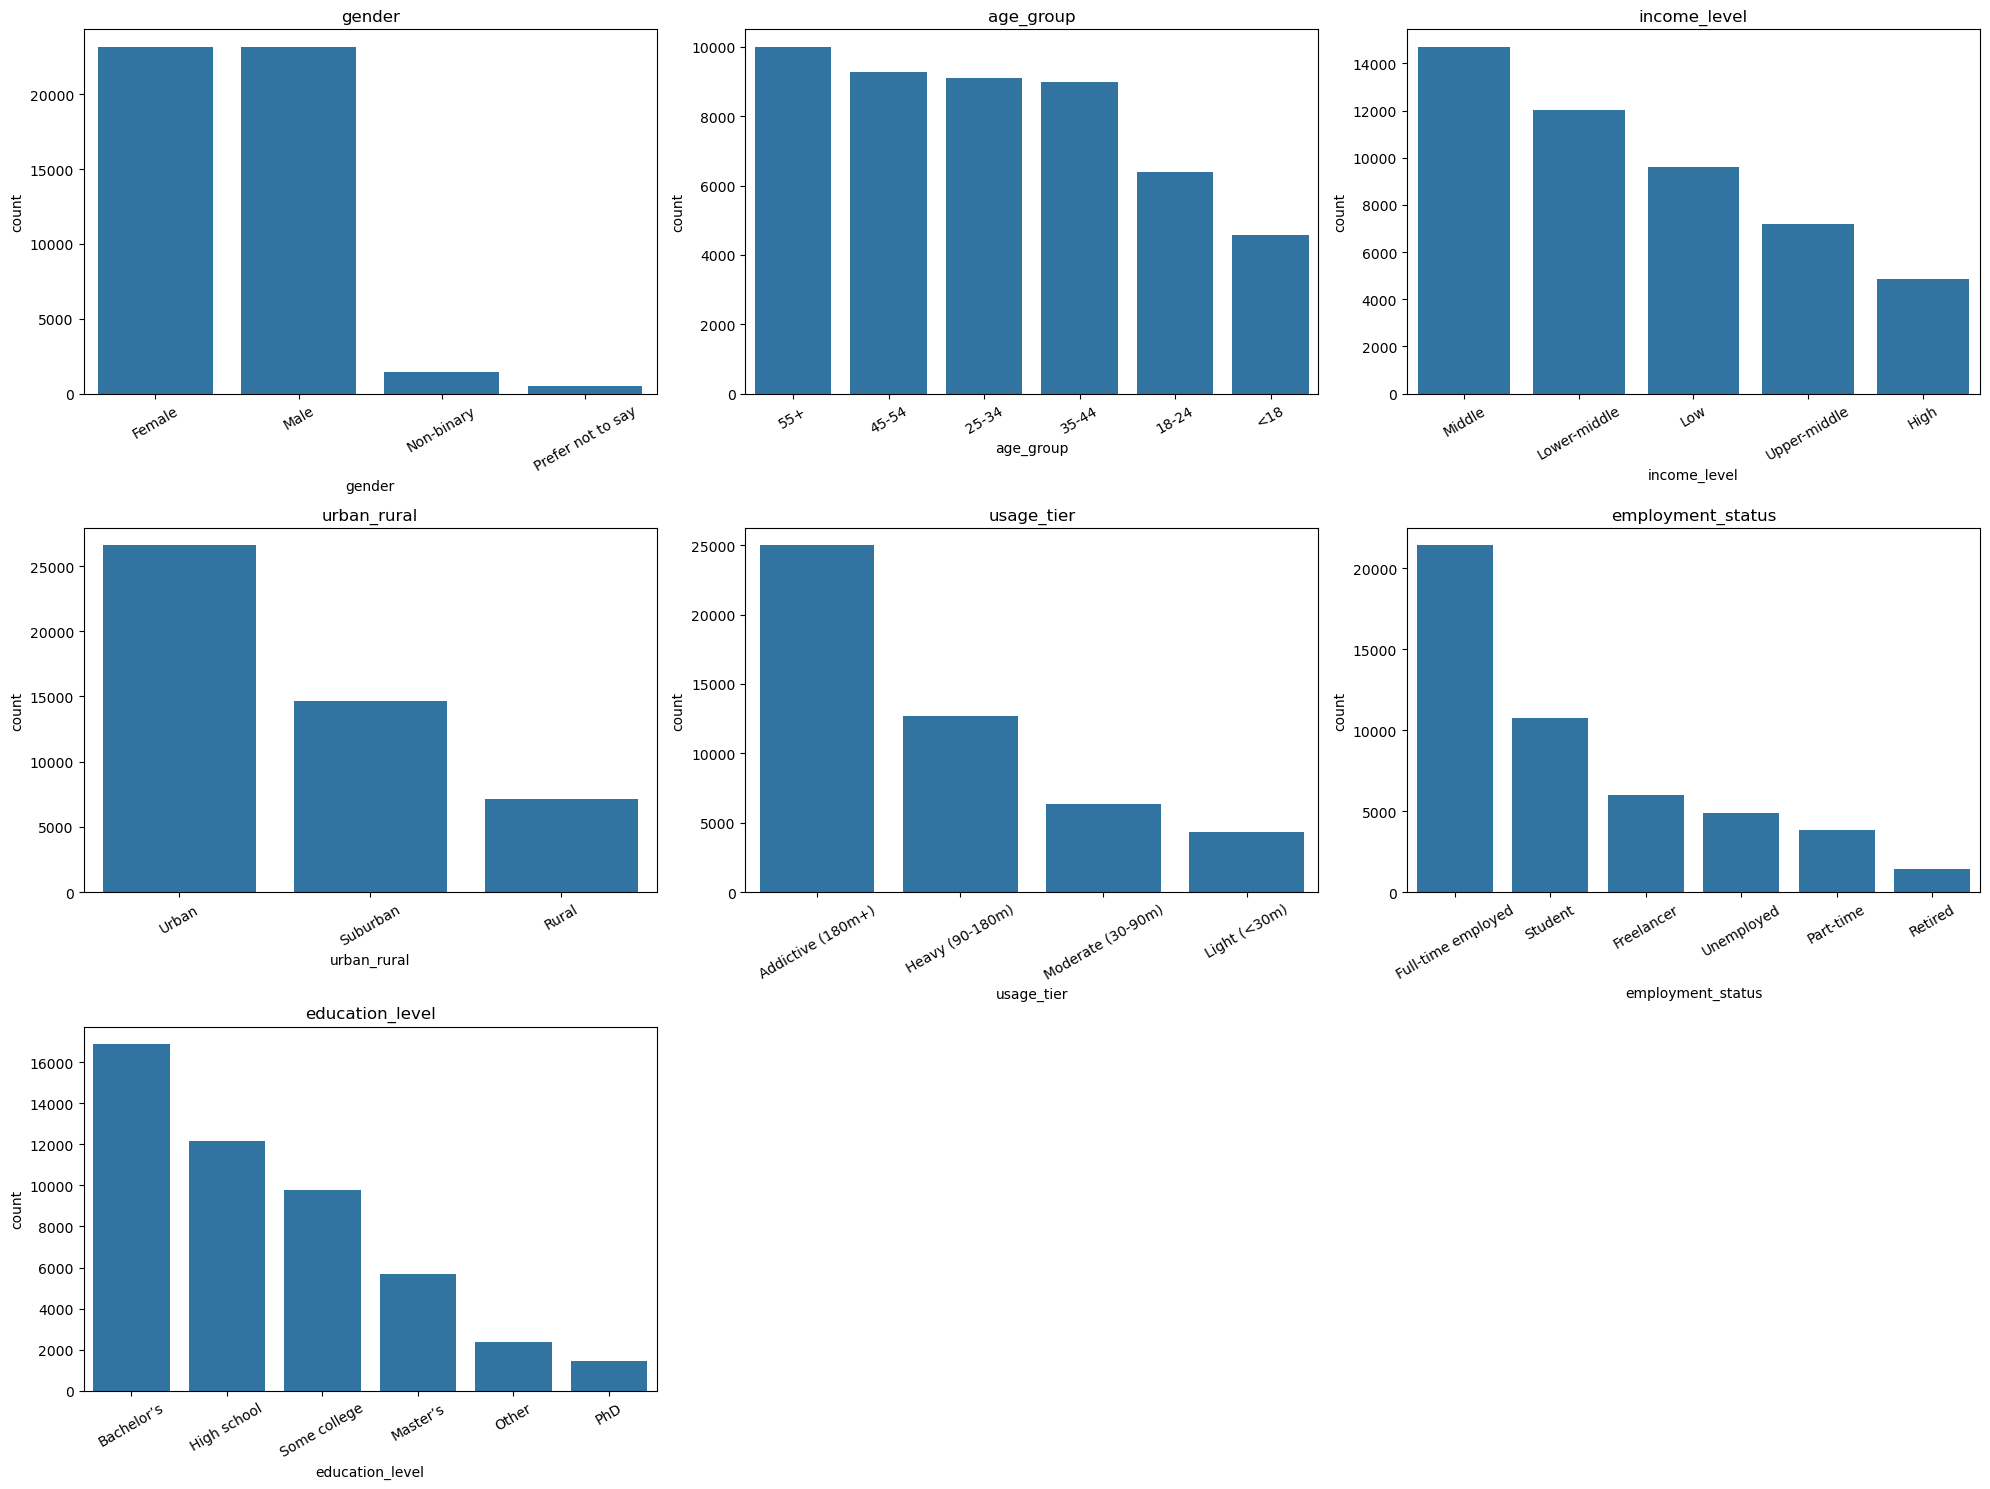

In [18]:
# Categorical (count plot)
def univariate_categorical(df, categorical_features):
    n_columns = 3
    n_rows = -(-len(categorical_features) // n_columns)
    plt.figure(figsize=(20, n_rows * 5))
    for i, col in enumerate(categorical_features):
        plt.subplot(n_rows, n_columns, i + 1)
        sns.countplot(x=col, data=df, order=df[col].value_counts().index)
        plt.title(col)
        plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

cat_plot_cols = ['gender', 'age_group', 'income_level', 'urban_rural',
                 'usage_tier', 'employment_status', 'education_level']
cat_plot_cols = [c for c in cat_plot_cols if c in df_eda.columns]
univariate_categorical(df_eda, cat_plot_cols)

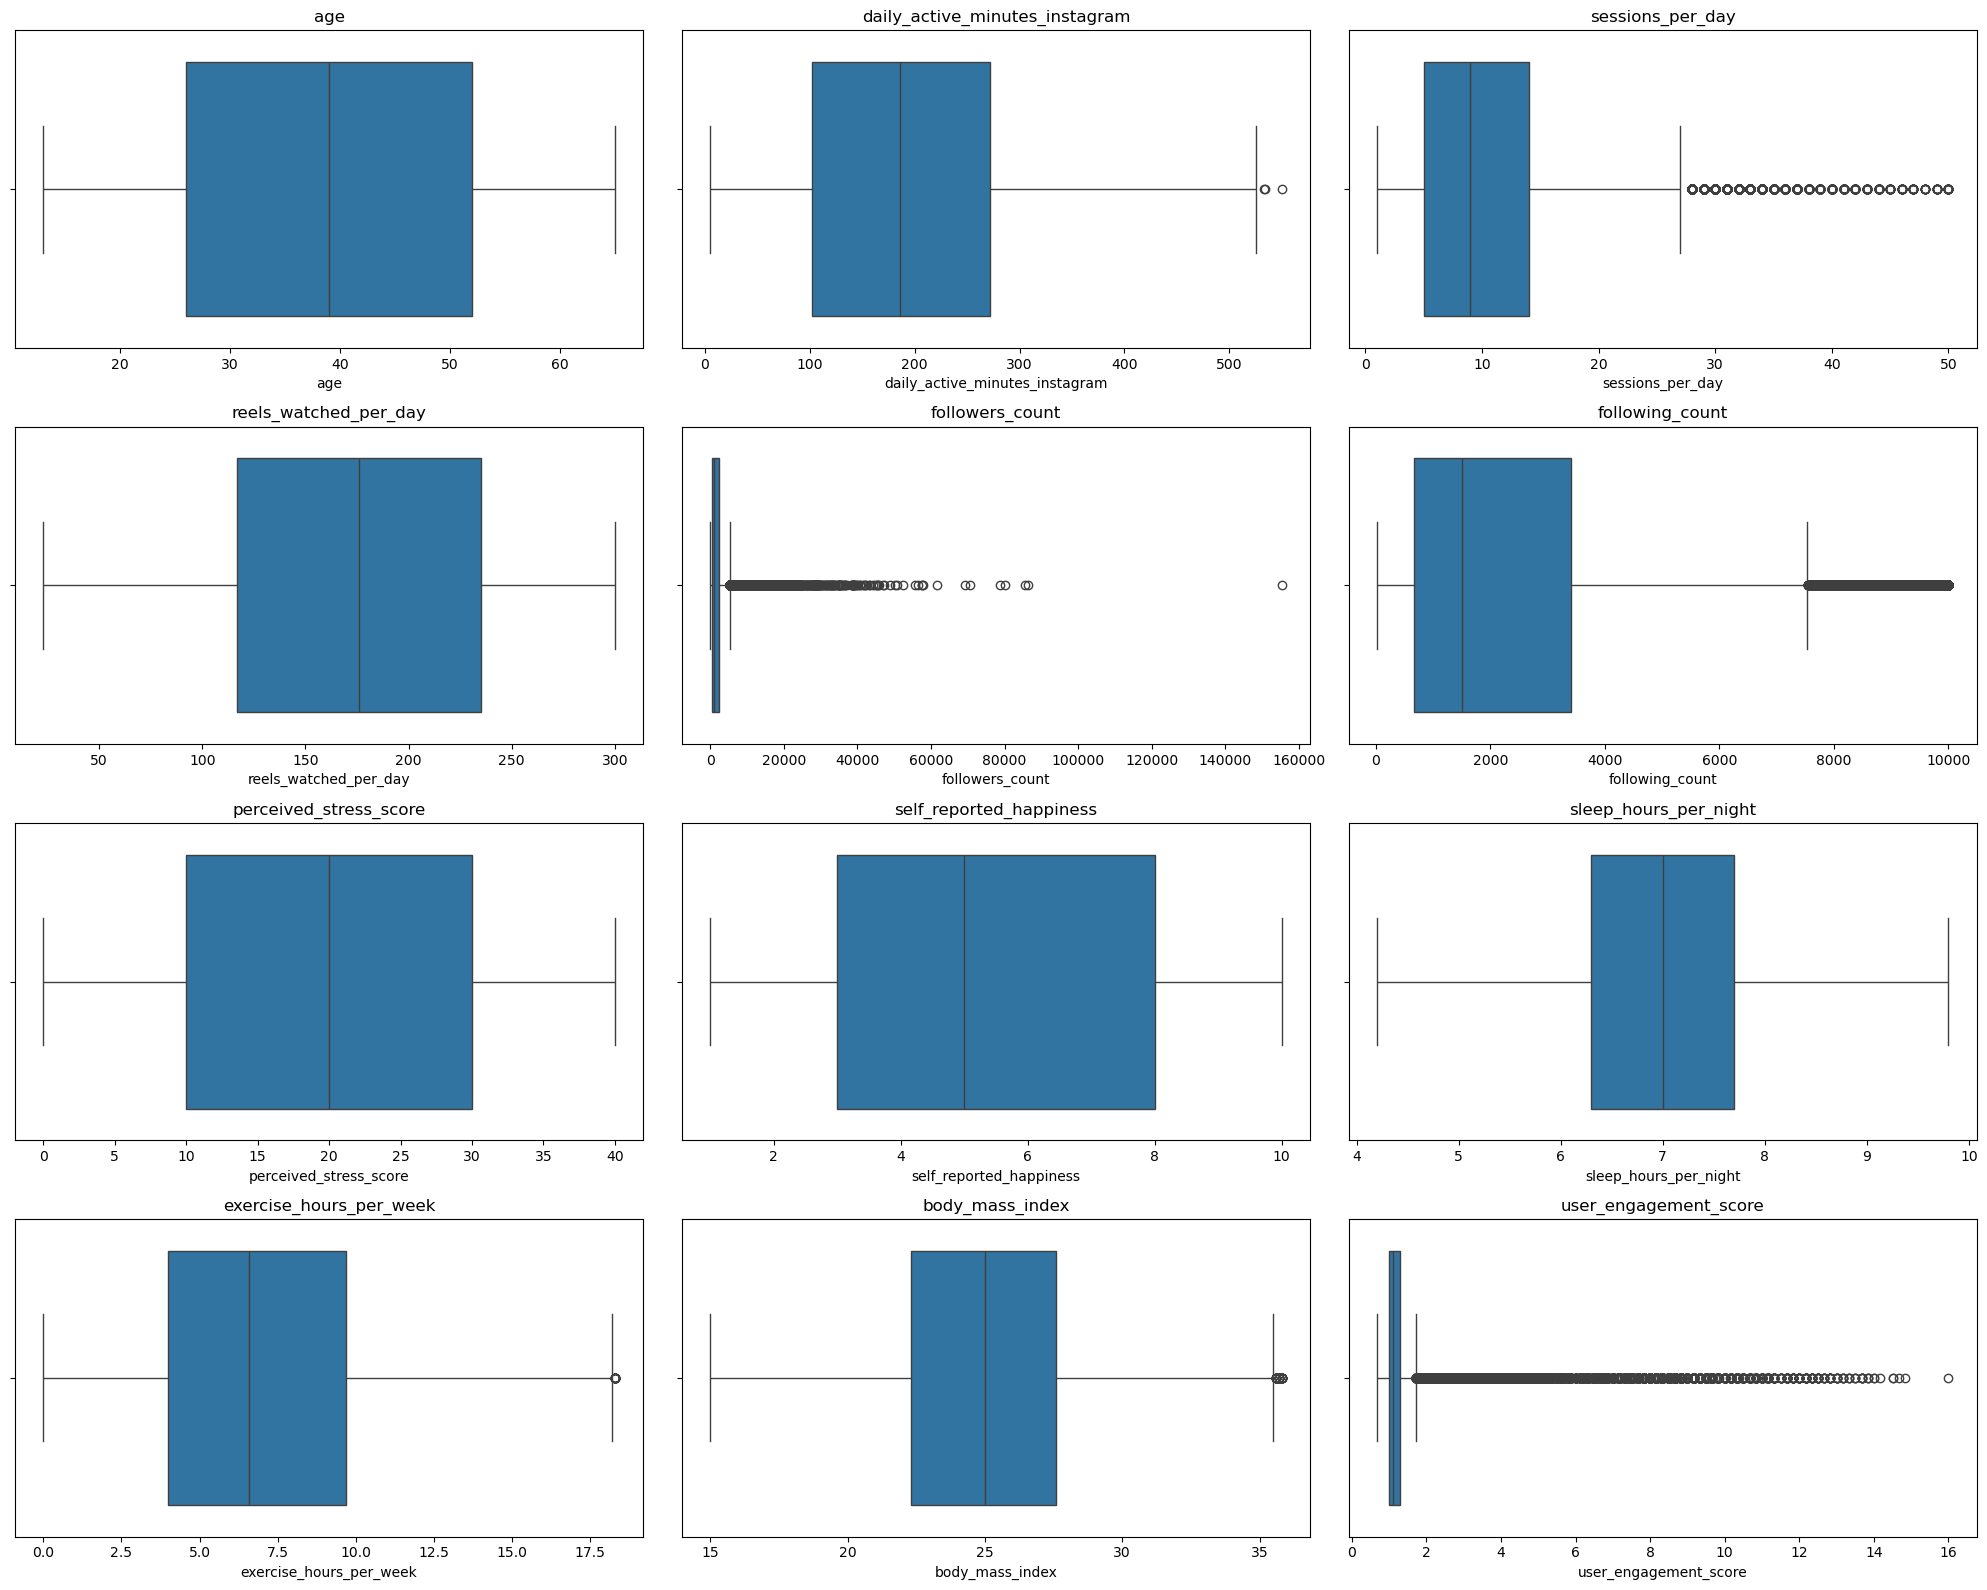

In [19]:
# Numerical ( box plot )
def univariate_numerical(df, numerical_features):
    n_columns = 3
    n_rows = -(-len(numerical_features) // n_columns)
    plt.figure(figsize=(20, n_rows * 4))
    for i, col in enumerate(numerical_features):
        plt.subplot(n_rows, n_columns, i + 1)
        sns.boxplot(x=col, data=df)
        plt.title(col)
    plt.tight_layout()
    plt.show()

univariate_numerical(df_eda, key_cols)

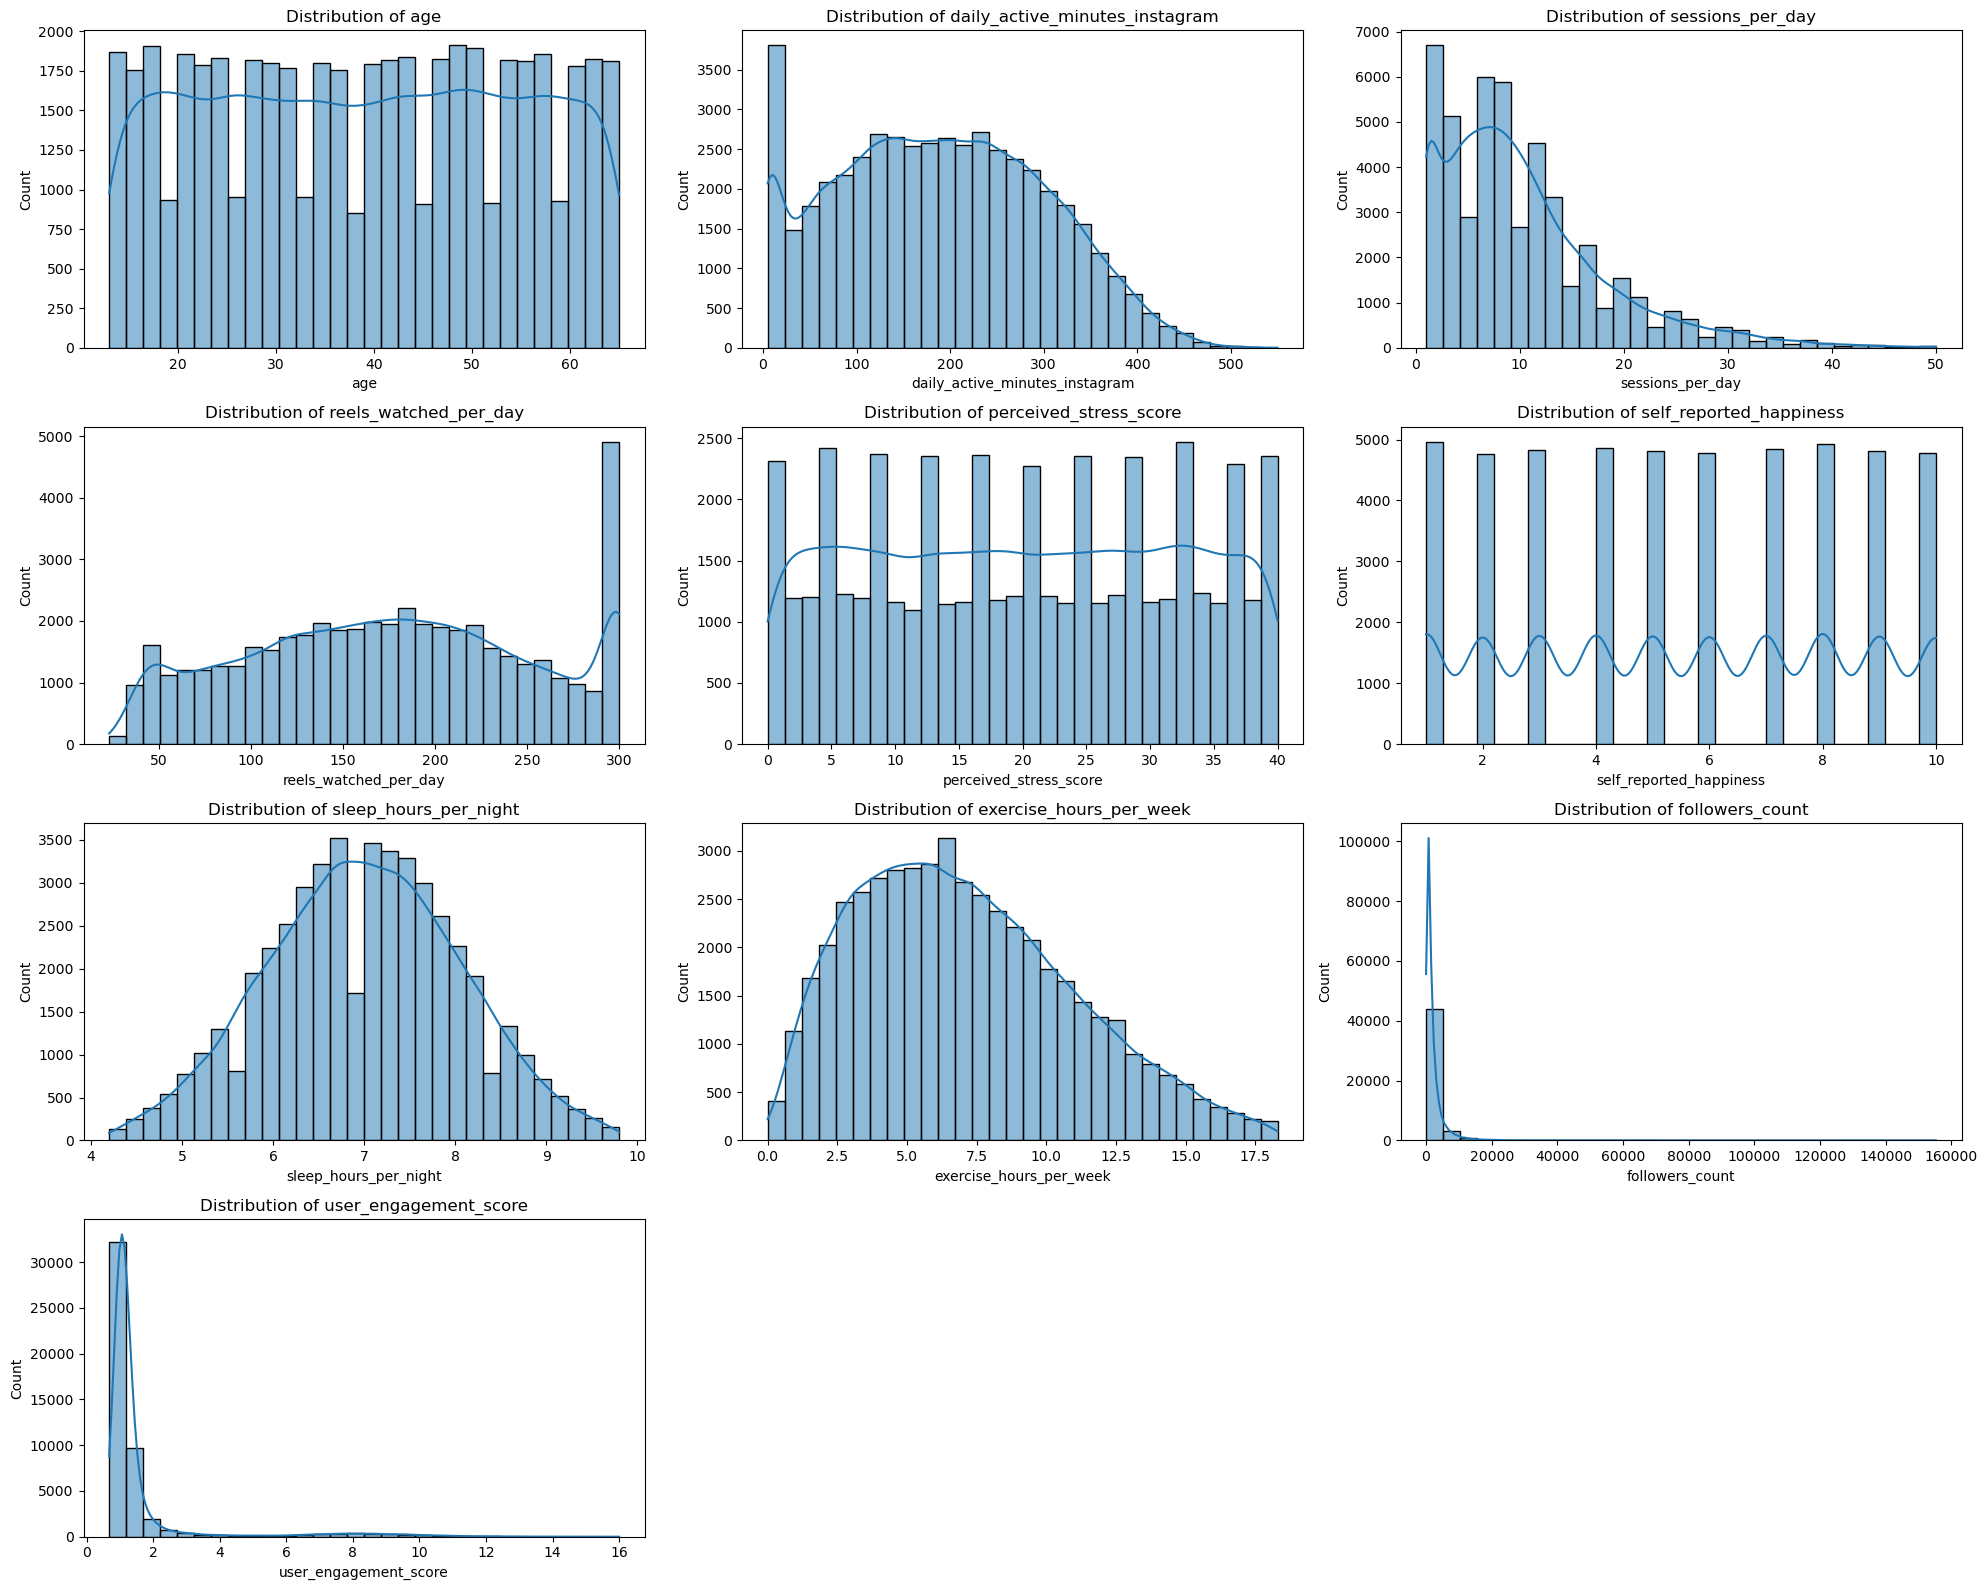

In [20]:
# Distribution plots (histogram) for key numerical variables
hist_cols = [
    "age", "daily_active_minutes_instagram", "sessions_per_day",
    "reels_watched_per_day", "perceived_stress_score",
    "self_reported_happiness", "sleep_hours_per_night",
    "exercise_hours_per_week", "followers_count", "user_engagement_score"
]
hist_cols = [c for c in hist_cols if c in df_eda.columns]

n_cols = 3
n_rows = -(-len(hist_cols) // n_cols)
plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(hist_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_eda[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

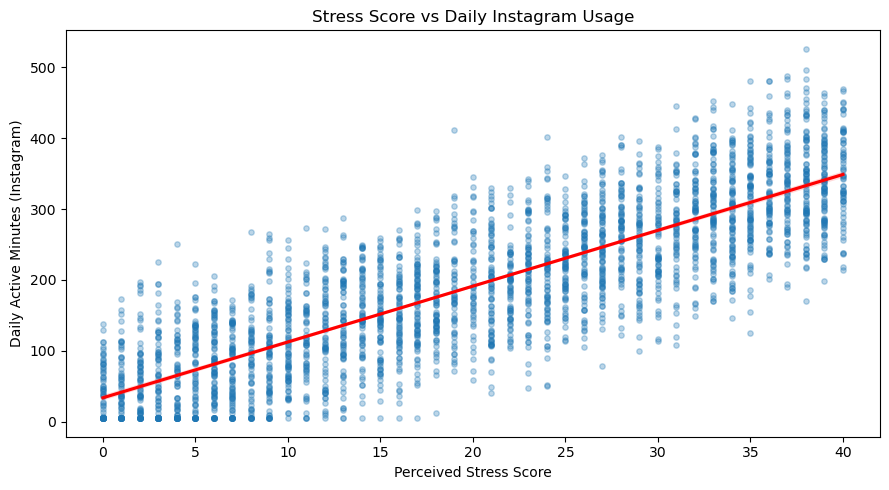

In [21]:
# 1. Stress vs Instagram usage time (scatter + trend)

plt.figure(figsize=(9, 5))
sample = df_eda.sample(3000, random_state=1)
sns.regplot(data=sample, x='perceived_stress_score', y='daily_active_minutes_instagram',
            scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
plt.title("Stress Score vs Daily Instagram Usage")
plt.xlabel("Perceived Stress Score")
plt.ylabel("Daily Active Minutes (Instagram)")
plt.tight_layout()
plt.show()

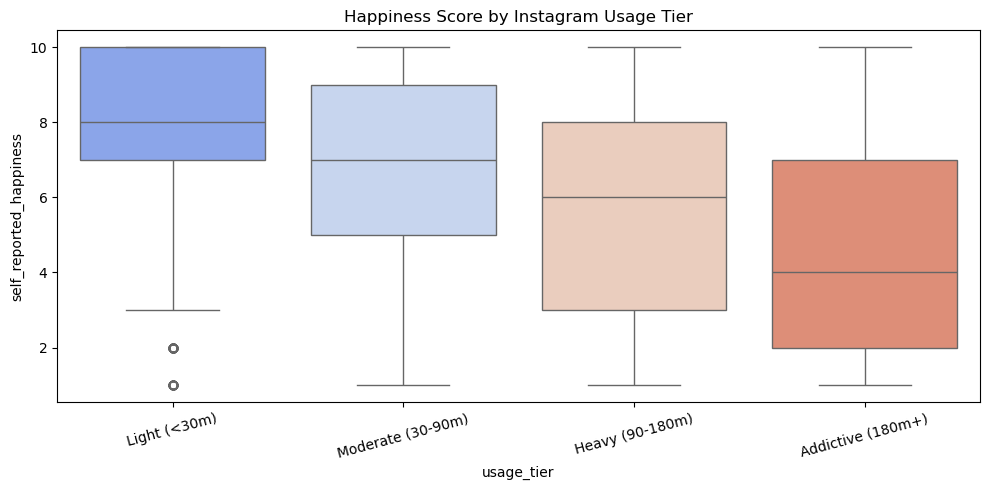

In [22]:
# 2. Happiness by usage tier (boxplot)
plt.figure(figsize=(10, 5))
order = ['Light (<30m)', 'Moderate (30-90m)', 'Heavy (90-180m)', 'Addictive (180m+)']
order = [o for o in order if o in df_eda['usage_tier'].cat.categories]
sns.boxplot(data=df_eda, x='usage_tier', y='self_reported_happiness',
            order=order, palette='coolwarm')
plt.title("Happiness Score by Instagram Usage Tier")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



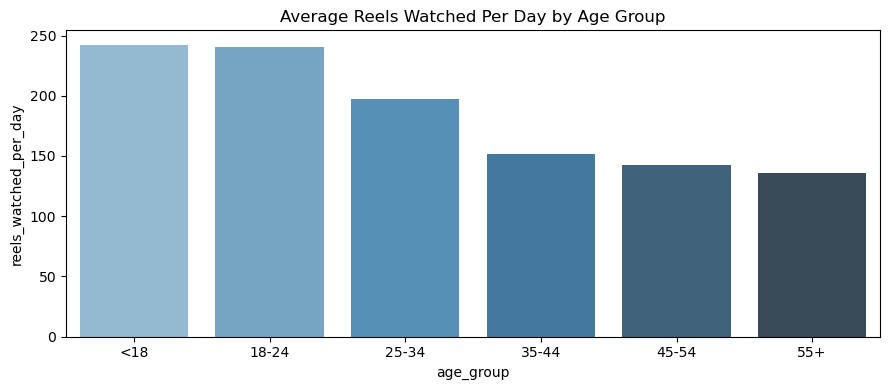

In [23]:
# 3. Age group vs reels watched (barplot)
age_reels = df_eda.groupby('age_group', observed=True)['reels_watched_per_day'].mean().reset_index()
plt.figure(figsize=(9, 4))
sns.barplot(data=age_reels, x='age_group', y='reels_watched_per_day', palette='Blues_d')
plt.title("Average Reels Watched Per Day by Age Group")
plt.tight_layout()
plt.show()

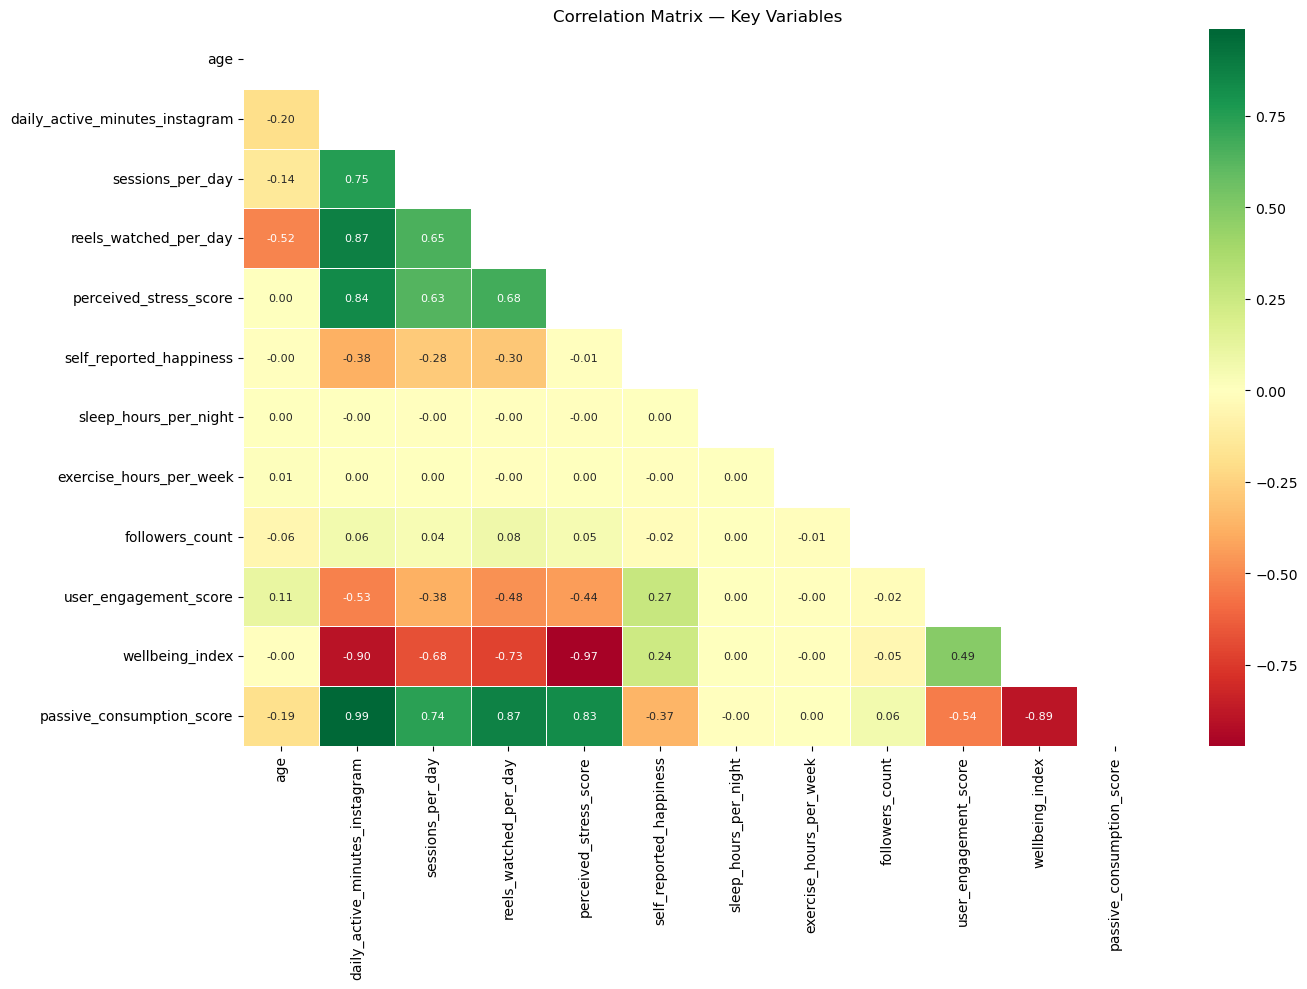

In [24]:
# 4. Correlation heatmap
heatmap_cols = [
    "age", "daily_active_minutes_instagram", "sessions_per_day",
    "reels_watched_per_day", "perceived_stress_score",
    "self_reported_happiness", "sleep_hours_per_night",
    "exercise_hours_per_week", "followers_count", "user_engagement_score",
    "wellbeing_index", "passive_consumption_score"
]
heatmap_cols = [c for c in heatmap_cols if c in df_eda.columns]

corr_matrix = df_eda[heatmap_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Matrix — Key Variables")
plt.tight_layout()
plt.show()

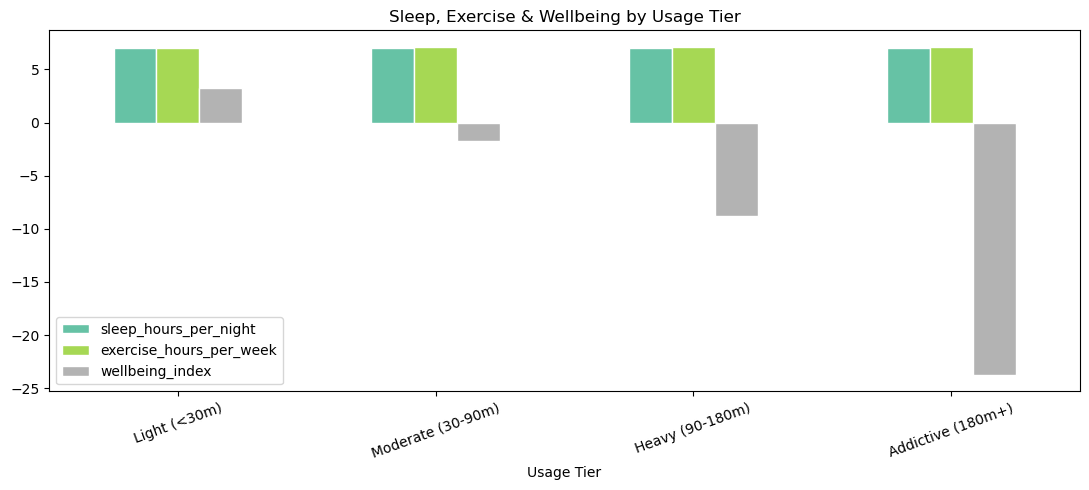

In [25]:
# 5. Lifestyle vs usage tier (grouped bar)
lifestyle_cols = ['sleep_hours_per_night', 'exercise_hours_per_week', 'wellbeing_index']
group_data = df_eda.groupby('usage_tier', observed=True)[lifestyle_cols].mean()
group_data.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='white')
plt.title("Sleep, Exercise & Wellbeing by Usage Tier")
plt.xlabel("Usage Tier")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Predicting above-average stress: two models compared

To see which usage behaviours drive stress, I first rank the variables by how strongly they correlate with stress and happiness, then train two classifiers, a Logistic Regression and a Decision Tree, to predict whether a user has above-average stress (above the median). I use the same features and the same train/test split, and compare the two with accuracy, precision, recall, f1, a confusion matrix, and ROC AUC, plus confusion-matrix, ROC-curve, and feature-importance plots.

In [26]:
# Which variables move most with stress and happiness (absolute correlation).
# Exclude the two targets and wellbeing_index (built from them) so the ranking shows real drivers.
exclude = ['perceived_stress_score', 'self_reported_happiness', 'wellbeing_index']
num = df_eda.select_dtypes(include='number').drop(columns=exclude)
infl = pd.DataFrame({
    'vs_stress': num.corrwith(df_eda['perceived_stress_score']),
    'vs_happiness': num.corrwith(df_eda['self_reported_happiness']),
})
infl['abs_stress'] = infl['vs_stress'].abs()
infl = infl.sort_values('abs_stress', ascending=False).drop(columns='abs_stress').round(3)
infl.head(10)

,vs_stress,vs_happiness
daily_active_minutes_instagram,0.836,-0.376
passive_consumption_score,0.831,-0.366
likes_given_per_day,0.821,-0.368
time_on_feed_per_day,0.816,-0.365
stories_viewed_per_day,0.816,-0.347
comments_written_per_day,0.790,-0.353
time_on_reels_per_day,0.784,-0.350
dms_received_per_week,0.772,-0.343
dms_sent_per_week,0.750,-0.337
time_on_messages_per_day,0.750,-0.340


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

# Binary target: above-average (above median) stress
features = ['daily_active_minutes_instagram', 'passive_consumption_score',
            'sessions_per_day', 'reels_watched_per_day']
X = df_eda[features]
y = (df_eda['perceived_stress_score'] > df_eda['perceived_stress_score'].median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Two classifiers on the same task
logit = LogisticRegression(max_iter=1000)
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
logit.fit(X_train, y_train)
tree.fit(X_train, y_train)

pred_lr = logit.predict(X_test)
pred_dt = tree.predict(X_test)

print('Logistic Regression')
print(classification_report(y_test, pred_lr))
print('Decision Tree (max_depth=4)')
print(classification_report(y_test, pred_dt))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      6247
           1       0.85      0.84      0.85      5842

    accuracy                           0.85     12089
   macro avg       0.85      0.85      0.85     12089
weighted avg       0.85      0.85      0.85     12089

Decision Tree (max_depth=4)
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      6247
           1       0.85      0.84      0.85      5842

    accuracy                           0.85     12089
   macro avg       0.85      0.85      0.85     12089
weighted avg       0.85      0.85      0.85     12089



In [28]:
# Compare both models on shared metrics (ROC AUC uses predicted probabilities)
proba_lr = logit.predict_proba(X_test)[:, 1]
proba_dt = tree.predict_proba(X_test)[:, 1]

compare = pd.DataFrame({
    'Logistic Regression': [accuracy_score(y_test, pred_lr), precision_score(y_test, pred_lr),
                            recall_score(y_test, pred_lr), f1_score(y_test, pred_lr),
                            roc_auc_score(y_test, proba_lr)],
    'Decision Tree': [accuracy_score(y_test, pred_dt), precision_score(y_test, pred_dt),
                      recall_score(y_test, pred_dt), f1_score(y_test, pred_dt),
                      roc_auc_score(y_test, proba_dt)],
}, index=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']).round(3)
compare

,Logistic Regression,Decision Tree
accuracy,0.852,0.853
precision,0.850,0.854
recall,0.843,0.840
f1,0.846,0.847
roc_auc,0.935,0.933


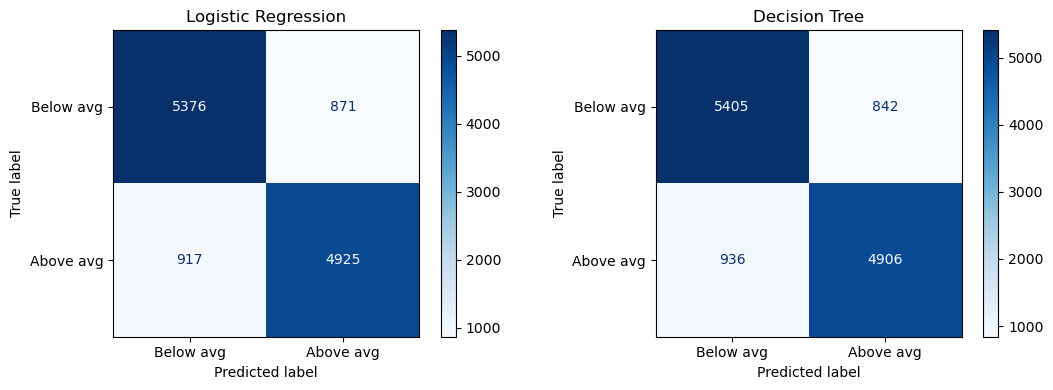

In [29]:
# Confusion matrices for both models 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr, ax=axes[0], cmap='Blues',
                                        display_labels=['Below avg', 'Above avg'])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, pred_dt, ax=axes[1], cmap='Blues',
                                        display_labels=['Below avg', 'Above avg'])
axes[1].set_title('Decision Tree')
plt.tight_layout()
plt.show()

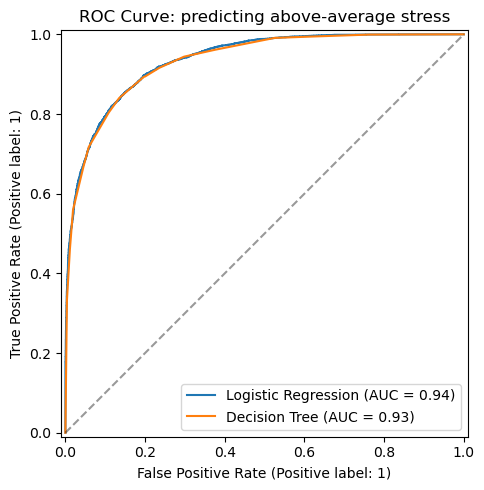

In [30]:
# ROC curves for both models on one axis
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(logit, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(tree, X_test, y_test, ax=ax, name='Decision Tree')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title('ROC Curve: predicting above-average stress')
plt.tight_layout()
plt.show()

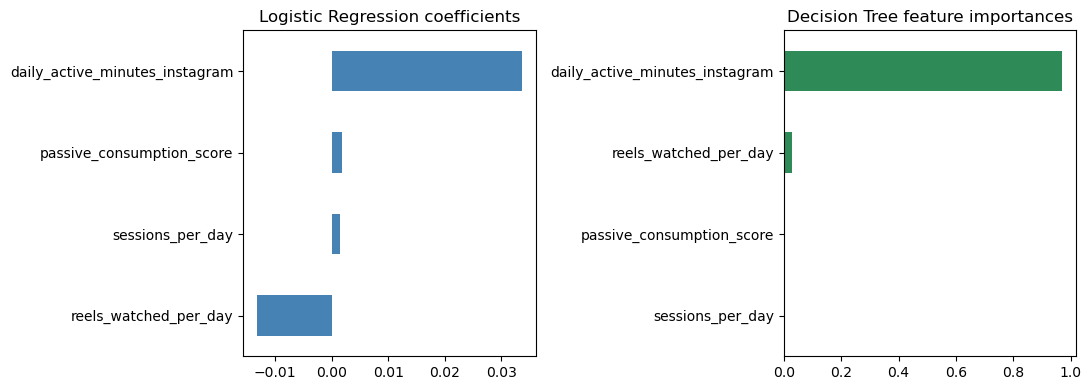

In [31]:
# What each model relies on: logistic coefficients vs tree feature importances
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(logit.coef_[0], index=features).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression coefficients')
pd.Series(tree.feature_importances_, index=features).sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Decision Tree feature importances')
plt.tight_layout()
plt.show()

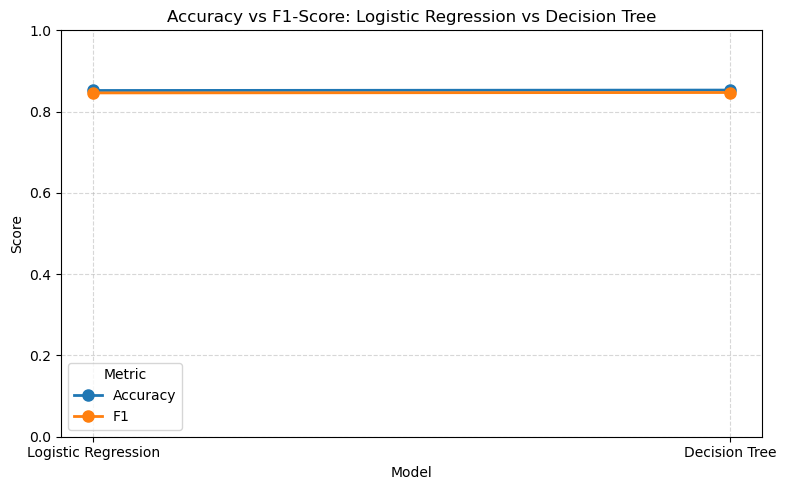

In [34]:
# Line chart: Accuracy vs F1-score across both models
metrics_to_plot = ['accuracy', 'f1']
models = ['Logistic Regression', 'Decision Tree']

plt.figure(figsize=(8, 5))

for metric in metrics_to_plot:
    values = [compare.loc[metric, model] for model in models]
    plt.plot(models, values, marker='o', linewidth=2, markersize=8, label=metric.capitalize())

plt.title('Accuracy vs F1-Score: Logistic Regression vs Decision Tree')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

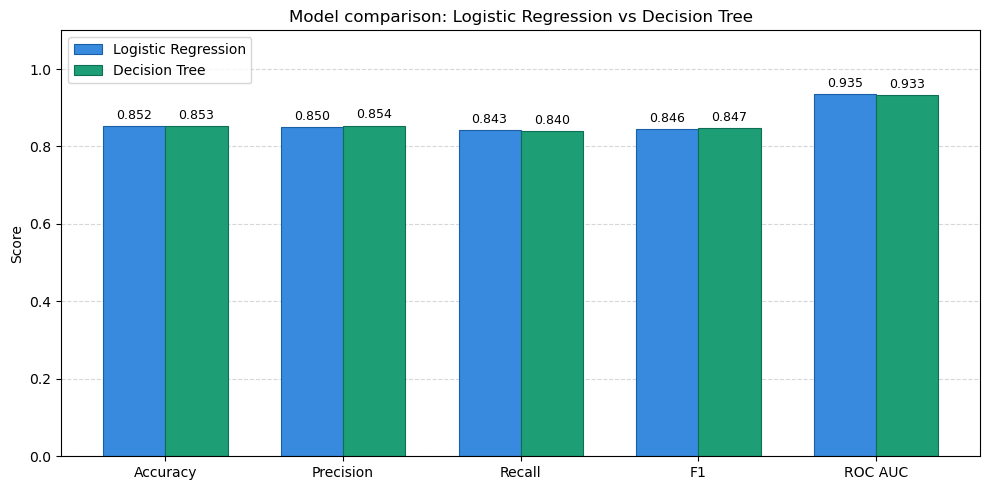

In [35]:
# Grouped bar chart: all metrics compared across both models
import numpy as np

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
labels  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']

lr_vals = [compare.loc[m, 'Logistic Regression'] for m in metrics]
dt_vals = [compare.loc[m, 'Decision Tree']        for m in metrics]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_lr = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression',
                 color='#378ADD', edgecolor='#185FA5', linewidth=0.8)
bars_dt = ax.bar(x + width/2, dt_vals, width, label='Decision Tree',
                 color='#1D9E75', edgecolor='#0F6E56', linewidth=0.8)

# Value labels on top of each bar
ax.bar_label(bars_lr, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars_dt, fmt='%.3f', padding=3, fontsize=9)

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_title('Model comparison: Logistic Regression vs Decision Tree')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Research questions and findings

This project asks how Instagram usage relates to wellbeing and lifestyle. Because the sample is large, I look at the size of each relationship, not p-values.

1. Does more usage relate to higher stress? Yes. Daily active minutes correlate about +0.84 with perceived stress (heatmap; stress-vs-usage scatter). Passive scrolling is almost as strong (+0.83).

2. Does more usage relate to lower happiness? Yes, moderately. Daily minutes correlate about -0.38 with happiness, and happiness falls from the Light to the Addictive tier (happiness-by-tier boxplot).

3. Does wellbeing differ across usage tiers? Yes, steeply. In the sleep/exercise/wellbeing-by-tier chart, the wellbeing index drops from about +3 in the Light tier to about -24 in the Addictive tier. About 52% of users are in the Addictive tier (usage_tier count plot).

4. Is heavy usage linked to less sleep or exercise? No. Usage correlates about 0.00 with both, and in the same tier chart sleep and exercise stay flat near 7 across every tier. The wellbeing effect is psychological, not physical.

5. Does reel watching differ by age? Yes. Average reels watched per day falls from about 242 for under-18s to about 136 for the 55+ group (reels-by-age chart). Younger users watch far more reels.

Evaluation of analytical methods and metrics

This project uses a few simple, explainable methods rather than complex models, so every result can be defended in the presentation.

Sampling check. I compared the 50k sample means against the full population (representativeness cell). Every key variable matched within about 0.6%, so the sample is a fair stand-in for the whole dataset.

Outlier handling. I used the IQR rule on the physiological columns only, and the data quality table shows how many rows that removed. Engagement columns were left alone because high values there are real, not errors.

Relationships. I used Pearson correlation, reading strength from the size of r rather than p-values because the sample is large, plus group means across usage_tier and age_group. The strongest links are daily usage and passive scrolling with stress (about +0.84 and +0.83).

Prediction and model comparison. I framed an above-average-stress flag (stress above the median) and trained two classifiers, a Logistic Regression and a Decision Tree, on the same features and train/test split. I judged them with accuracy, precision, recall, f1, a confusion matrix, and ROC AUC, and visualised the results with confusion matrices, ROC curves, and feature-importance bars. The two models score similarly and agree that daily active minutes and passive consumption are the main drivers, which backs up the correlation result. The target is balanced by the median split, so accuracy is a fair headline metric and ROC AUC confirms the ranking.

Limits of the methods. Correlation and these models show association, not cause; the data is a single snapshot and self-reported; and because the sample is so large, almost anything looks statistically significant, so I rely on effect size and metric values instead of p-values.

Insights and recommendations (for a platform digital-wellbeing / product team)

R1. Stress and lower wellbeing rise steadily with usage (heatmap; tier chart). Show a gentle "time spent today" reminder past about 90 minutes, and a stronger one past 180 minutes.

R2. The strongest single link is passive scrolling (passive_consumption about +0.83 with stress). Nudge heavy users away from passive feed/reels scrolling toward active, interactive use.

R3. Usage has about 0 correlation with sleep or exercise (heatmap; tier chart). Do not build wellbeing messaging around sleep/exercise - measure success on stress and happiness instead.

R4. About 52% of users are in the Addictive tier and have the worst wellbeing (count plot; tier chart). Make this group the priority segment, and treat the Heavy tier as an early-warning band.

R5. Under-25s watch far more reels than over-45s (reels-by-age chart). Focus reel-pacing and break interventions on younger cohorts, where consumption is highest.

Risks and considerations. Usage reminders and nudges can annoy users and may cut time-on-app, so they should be tested with an A/B trial before a full rollout. These results are associations, not proof of cause, so an intervention may not lower stress as much as the numbers suggest. Targeting should be based on usage behaviour rather than age or other demographics, to avoid unfair or discriminatory treatment of users.

Limitations

1. Relationship, not cause. The data is a single snapshot, so I cannot say usage causes stress; more stressed people might also use Instagram more.

2. wellbeing_index = happiness - stress combines two different scales (happiness 1-10, stress 0-40), so it goes strongly negative and its raw size should not be over-read; it is a constructed measure, not a validated one.

3. Self-reported. Happiness and stress are self-reported and can be biased.

4. Single platform, single time point. No trend over time and no comparison with other platforms; recommendations should be validated on other data before acting.

Conclusion

Using Instagram more is strongly linked to higher stress and lower happiness, and the link grows steadily from the Light tier to the Addictive tier, where about half of users sit. Usage is not linked to sleep or exercise, so the wellbeing story is about how people feel, not their physical habits, and younger users watch far more reels. The practical response is simple and targeted: gentle usage reminders for heavy users, a push away from passive scrolling, prioritising the Addictive tier and younger cohorts, and measuring success on stress and happiness.